# Zero-spend re-analysis: bracketing CIs on the temporal Mode-A gap (R1)

A runnable demo of the **R1** deliverable from the evaluation artifact
*"Zero-spend re-analysis: bracketing CIs, CLUTRR coverage, contribution split"*.

**What it does.** A pure re-analysis (**$0 LLM spend**; numpy only) of the temporal
point-algebra natural-text experiment. It re-derives a confidence interval on the gap between
the closure-certified **Mode-A** selective accuracy and four baselines (PoT, SC, naive, raw) at a
matched-coverage operating point, and shows:

1. The **published** matched-coverage-gap bootstrap was *buggy*: it re-derived the target
   coverage **inside** each resample, so the resampled gap was a **different estimator** than the
   headline point gap. Its CI did **not** bracket its own point estimate.
2. The **corrected** bootstrap holds the operating point **FIXED** across resamples. Its CI
   **brackets** the point gap — and, once correctly centered, **includes 0** for the PoT/SC
   gateways. So the published significance was a *bootstrap artifact*: on natural temporal text
   the comparative win is **marginal**, and the transferable contribution is the gold-free
   abstain-on-collapse **certificate**, not selective-accuracy dominance.

The demo runs on a curated **100-record** subset of the 600 per-query records (the full run uses
all 600 and reproduces the published point estimates exactly). The bootstrap helper functions are
copied **verbatim** from the original `eval.py`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- NOT pre-installed on Colab, always install (matches the original eval.py dependency)
_pip('loguru==0.7.3')

# numpy, matplotlib -- pre-installed on Colab; install locally to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
from loguru import logger

import matplotlib.pyplot as plt   # notebook visualization (not in the original CLI script)

# logger configuration -- same as the original eval.py
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-4/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
records = data["records"]                              # per-query (answered, pred, correct, conf) per method
H1_PUBLISHED = data["H1_matched_coverage_published"]   # full-600 published reference values
print(f"Loaded {len(records)} temporal per-query records "
      f"(demo subset of {data['n_records_full']} from {data['source_id']}).")

Loaded 100 temporal per-query records (demo subset of 600 from art_OETjJkketEVS).


## Config

All tunable parameters. The bootstrap is pure-numpy and fast, so the demo uses the **original**
`eval.py` values. `B` is the number of bootstrap resamples — lower it (e.g. `2000`) for a quicker
run, raise it for tighter quantiles.

In [5]:
# --------------------------------------------------------------------------- #
# config  (original eval.py values)
# --------------------------------------------------------------------------- #
SEED = 20260617       # original: 20260617
B = 10000             # bootstrap resamples. original: 10000  (try 2000 for a faster demo)
ALPHA = 0.05          # original: 0.05  -> 95% CIs

logger.info(f"config: SEED={SEED} B={B} ALPHA={ALPHA}")

22:24:56|INFO   |config: SEED=20260617 B=10000 ALPHA=0.05


## Risk-coverage curve + bootstrap helpers (verbatim from `eval.py`)

These are copied unchanged from the original script:

- `curve` / `acc_at_coverage` — build the sorted-by-confidence risk-coverage curve and interpolate
  selective accuracy at a target coverage.
- `old_buggy_gap_boot` — reproduces the **published (buggy)** bootstrap: it re-derives the target
  coverage `mc` *inside* each resample and interpolates the baseline at that **varying** `mc`
  (the bug — the resampled gap becomes a different estimator than the point gap).
- `fixed_set_gap_boot` — the **corrected** bootstrap: the operating point is **FIXED** on the full
  sample (Mode-A's fixed answered set vs the baseline's fixed top-k-by-conf matched set); each
  resample just recomputes accuracies over those fixed sets.
- `fixed_mc_interp_gap_boot` — the plan's "equivalent" fix (fixed `m_cov` passed as a constant).
- `holm` — Holm step-down adjusted p-values. `_r` — NaN/inf-safe rounding for JSON.

In [6]:
def _r(x, n=6):
    """Round, NaN/inf-safe (JSON cannot hold NaN/inf)."""
    if x is None:
        return None
    try:
        xf = float(x)
    except (TypeError, ValueError):
        return x
    if not np.isfinite(xf):
        return None
    return round(xf, n)


def curve(records):
    """records: list of {answered,correct,conf}. Return (pts, nat_cov, nat_acc).
    pts: sorted-by-conf-desc cumulative (coverage=k/N, selective_acc=cum_correct/k)."""
    n = len(records)
    ans = [(r["conf"], r["correct"]) for r in records
           if r["answered"] and r["correct"] is not None]
    if n == 0:
        return [], 0.0, float("nan")
    ans.sort(key=lambda x: -x[0])
    pts, cum = [], 0
    for k, (_, c) in enumerate(ans, start=1):
        cum += c
        pts.append((k / n, cum / k))
    nat_cov = len(ans) / n
    nat_acc = (cum / len(ans)) if ans else float("nan")
    return pts, nat_cov, nat_acc


def acc_at_coverage(pts, target):
    """Interpolate selective accuracy at a target coverage. NaN if target > max coverage."""
    if not pts:
        return float("nan")
    if target <= pts[0][0]:
        return pts[0][1]
    if target > pts[-1][0] + 1e-9:
        return float("nan")
    for i in range(1, len(pts)):
        c0, a0 = pts[i - 1]
        c1, a1 = pts[i]
        if c0 <= target <= c1:
            if c1 == c0:
                return a1
            w = (target - c0) / (c1 - c0)
            return a0 + w * (a1 - a0)
    return pts[-1][1]


def old_buggy_gap_boot(method_by_doc, base_by_doc, seed=SEED, n_boot=B):
    """Reproduce the PUBLISHED (buggy) matched_coverage_gap bootstrap:
    inner loop RE-DERIVES the target coverage mc per resample and interpolates the
    baseline at that VARYING mc -> the gap distribution is a different estimator than
    the point gap (recenters on the volatile low-coverage baseline curve)."""
    docs = sorted(set(method_by_doc) | set(base_by_doc))
    nd = len(docs)
    rng = np.random.default_rng(seed)
    gaps = []
    for _ in range(n_boot):
        pick = [docs[i] for i in rng.integers(0, nd, nd)]
        mrec = [r for d in pick for r in method_by_doc.get(d, [])]
        brec = [r for d in pick for r in base_by_doc.get(d, [])]
        _, mc, ma = curve(mrec)
        bp, _, _ = curve(brec)
        ba = acc_at_coverage(bp, mc)          # <-- VARYING mc = the bug
        if ma == ma and ba == ba:
            gaps.append(ma - ba)
    if not gaps:
        return None
    lo, hi = np.quantile(gaps, [ALPHA / 2, 1 - ALPHA / 2])
    return {"ci95": [float(lo), float(hi)], "boot_p_gap_le_0": float(np.mean([g <= 0 for g in gaps])),
            "median": float(np.median(gaps)), "mean": float(np.mean(gaps)), "n_boot": len(gaps)}


def fixed_set_gap_boot(method_set_by_doc, base_set_by_doc, seed=SEED, n_boot=B):
    """CORRECTED bracketing bootstrap: the operating point is FIXED on the full sample.
    method_set_by_doc / base_set_by_doc map docid -> list of correctness values (0/1)
    for the FIXED answered set (method) and FIXED matched-coverage top-k set (baseline).
    Each resample recomputes accuracies over those FIXED sets present in the resample."""
    docs = sorted(set(method_set_by_doc) | set(base_set_by_doc))
    nd = len(docs)
    rng = np.random.default_rng(seed)
    gaps = []
    for _ in range(n_boot):
        idx = rng.integers(0, nd, nd)
        mvals, bvals = [], []
        for i in idx:
            d = docs[i]
            mvals.extend(method_set_by_doc.get(d, []))
            bvals.extend(base_set_by_doc.get(d, []))
        if mvals and bvals:
            gaps.append(float(np.mean(mvals)) - float(np.mean(bvals)))
    if not gaps:
        return None
    lo, hi = np.quantile(gaps, [ALPHA / 2, 1 - ALPHA / 2])
    return {"ci95": [float(lo), float(hi)], "boot_p_gap_le_0": float(np.mean([g <= 0 for g in gaps])),
            "median": float(np.median(gaps)), "mean": float(np.mean(gaps)), "n_boot": len(gaps)}


def fixed_mc_interp_gap_boot(modeA_by_doc, base_by_doc, m_cov, seed=SEED, n_boot=B):
    """The plan's 'equivalent' fix: reuse the experiment's curve/interpolation but pass the
    FULL-sample m_cov as a FIXED constant into the inner loop (replace the resampled mc).
    modeA_by_doc/base_by_doc map docid -> list of {answered,correct,conf}. Each resample:
    ma = resampled Mode-A natural selacc; ba = baseline acc interpolated at FIXED m_cov."""
    docs = sorted(set(modeA_by_doc) | set(base_by_doc))
    nd = len(docs)
    rng = np.random.default_rng(seed)
    gaps = []
    for _ in range(n_boot):
        idx = rng.integers(0, nd, nd)
        mrec, brec = [], []
        for i in idx:
            d = docs[i]
            mrec.extend(modeA_by_doc.get(d, []))
            brec.extend(base_by_doc.get(d, []))
        _, _, ma = curve(mrec)
        bp, _, _ = curve(brec)
        ba = acc_at_coverage(bp, m_cov)        # FIXED m_cov (not resampled)
        if ma == ma and ba == ba:
            gaps.append(ma - ba)
    if not gaps:
        return None
    lo, hi = np.quantile(gaps, [ALPHA / 2, 1 - ALPHA / 2])
    return {"ci95": [float(lo), float(hi)], "boot_p_gap_le_0": float(np.mean([g <= 0 for g in gaps])),
            "median": float(np.median(gaps)), "n_boot": len(gaps)}


def holm(pvals: dict, alpha=ALPHA):
    """Holm step-down adjusted p-values + reject flags."""
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    out, prev = {}, 0.0
    for rank, (name, p) in enumerate(items):
        adj = min(1.0, max(prev, (m - rank) * p))
        prev = adj
        out[name] = {"p": float(p), "p_adj": float(adj), "reject": bool(adj < alpha)}
    return out

## Step 1 — fix the Mode-A operating point

Mode-A only commits to a query when its closure does **not** collapse, so it answers a small
fraction (`coverage`). We compute that natural operating point **once** on the full sample and
freeze it: `k_target = round(coverage * N)` is the matched-coverage budget every baseline is held
to. `modeA_set_doc` maps each document to its frozen Mode-A correctness values (for the
doc-clustered resampling).

In [7]:
recs = records
N = len(recs)
# Mode-A natural operating point (FIXED once on the full sample)
modeA_ans = [r for r in recs if r["modeA"]["answered"] and r["modeA"]["correct"] is not None]
m_cov = len(modeA_ans) / N
m_acc = float(np.mean([r["modeA"]["correct"] for r in modeA_ans]))
k_target = int(round(m_cov * N))      # matched-coverage k

# FIXED Mode-A answered set -> docid -> [correct]
modeA_set_doc = {}
for r in modeA_ans:
    modeA_set_doc.setdefault(r["docid"], []).append(int(r["modeA"]["correct"]))

logger.info(f"Mode-A operating point: coverage={m_cov:.4f}  selective_acc={m_acc:.4f}  k_matched={k_target}  N={N}")

22:24:56|INFO   |Mode-A operating point: coverage=0.1800  selective_acc=0.6111  k_matched=18  N=100


## Step 2 — old (buggy) vs corrected bootstrap, per baseline

For each baseline we take its **fixed** top-`k_target`-by-confidence matched set, compute the point
gap `m_acc − base_acc`, then run three doc-clustered paired bootstraps:

- `old_buggy_gap_boot` — the published procedure (re-derives coverage inside each resample),
- `fixed_set_gap_boot` — the **corrected** fixed-operating-point bootstrap (**primary**),
- `fixed_mc_interp_gap_boot` — the "equivalent" fixed-`m_cov` interpolation variant.

We flag whether each CI **brackets** the point gap. The full-600 published values are shown for
reference (the demo's 100-record subset will not match them numerically, but reproduces the
**qualitative** pattern).

In [8]:
r1 = {"seed": SEED, "n_boot": B, "fixed_m_cov": _r(m_cov), "k_matched": k_target,
      "modeA_selective_accuracy": _r(m_acc), "baselines": {}}

for base in ("pot", "sc", "naive", "raw"):
    brecs = [r for r in recs if r[base]["answered"] and r[base]["correct"] is not None]
    # FIXED matched-coverage set = top-k_target by conf
    brecs_sorted = sorted(brecs, key=lambda r: -r[base]["conf"])
    kk = min(k_target, len(brecs_sorted))
    base_set = brecs_sorted[:kk]
    base_acc = float(np.mean([r[base]["correct"] for r in base_set])) if base_set else float("nan")
    point_gap = m_acc - base_acc

    base_set_doc = {}
    for r in base_set:
        base_set_doc.setdefault(r["docid"], []).append(int(r[base]["correct"]))

    # doc -> all-answered baseline records (for the interpolation variant + old reproduction)
    base_all_doc = {}
    for rr in brecs:
        base_all_doc.setdefault(rr["docid"], []).append(
            {"answered": True, "correct": rr[base]["correct"], "conf": rr[base]["conf"]})
    modeA_all_doc = {}
    for rr in modeA_ans:
        modeA_all_doc.setdefault(rr["docid"], []).append(
            {"answered": True, "correct": rr["modeA"]["correct"], "conf": rr["modeA"]["conf"]})

    new = fixed_set_gap_boot(modeA_set_doc, base_set_doc)                  # PRIMARY: fixed-set
    interp = fixed_mc_interp_gap_boot(modeA_all_doc, base_all_doc, m_cov)  # plan's 'equivalent' fix
    old = old_buggy_gap_boot(modeA_all_doc, base_all_doc)                  # reproduce buggy procedure
    new_ci = new["ci95"]
    brackets = bool(new_ci[0] <= point_gap <= new_ci[1])
    corrected_sig = bool(new_ci[0] > 0)   # one-sided: CI lower bound above 0

    pub = H1_PUBLISHED[f"modeA_vs_{base}"]
    r1["baselines"][base] = {
        "point_gap": _r(point_gap),
        "base_acc_at_matched_coverage": _r(base_acc),
        "published_full600_gap": _r(pub["gap"]),
        "published_full600_old_ci95": [_r(pub["ci95"][0]), _r(pub["ci95"][1])],
        "published_full600_old_boot_p": _r(pub["boot_p_gap_le_0"]),
        "reproduced_old_ci95": [_r(old["ci95"][0]), _r(old["ci95"][1])],
        "reproduced_old_boot_p": _r(old["boot_p_gap_le_0"]),
        "new_ci95": [_r(new_ci[0]), _r(new_ci[1])],
        "new_boot_p_gap_le_0": _r(new["boot_p_gap_le_0"]),
        "new_ci95_interp_variant": [_r(interp["ci95"][0]), _r(interp["ci95"][1])],
        "ci_brackets_point_estimate": brackets,
        "corrected_one_sided_significant": corrected_sig,
    }
    logger.info(f"R1 vs {base}: point={point_gap:+.4f}  "
                f"OLD_buggy_ci=[{old['ci95'][0]:+.4f},{old['ci95'][1]:+.4f}] (p={old['boot_p_gap_le_0']:.3f})  "
                f"NEW_fixed_ci=[{new_ci[0]:+.4f},{new_ci[1]:+.4f}] brackets={brackets} (p={new['boot_p_gap_le_0']:.3f})")

22:24:57|INFO   |R1 vs pot: point=+0.0000  OLD_buggy_ci=[-0.0033,+0.4983] (p=0.027)  NEW_fixed_ci=[-0.2917,+0.3025] brackets=True (p=0.517)


22:24:58|INFO   |R1 vs sc: point=+0.0556  OLD_buggy_ci=[+0.0269,+0.4726] (p=0.016)  NEW_fixed_ci=[-0.1842,+0.3112] brackets=True (p=0.347)


22:24:58|INFO   |R1 vs naive: point=+0.0000  OLD_buggy_ci=[-0.0987,+0.1250] (p=0.469)  NEW_fixed_ci=[-0.1154,+0.1250] brackets=True (p=0.556)


22:24:59|INFO   |R1 vs raw: point=-0.2222  OLD_buggy_ci=[+0.0690,+0.5317] (p=0.007)  NEW_fixed_ci=[-0.5000,+0.0368] brackets=True (p=0.956)


## Step 3 — Holm gatekeeping + the honest finding

H1's confirmatory family is `{vs PoT, vs SC}`. We Holm-adjust the corrected bootstrap p-values.
The honest result: once correctly centered, **neither gateway clears** — the corrected CIs include
0, so the published significance (`boot_p` ~0.007 / 0.0185) was a **bootstrap artifact**.

In [9]:
# Holm over the corrected confirmatory family {vs PoT, vs SC} (H1 gateways)
r1["holm_H1_corrected"] = holm({
    "H1_vs_PoT": r1["baselines"]["pot"]["new_boot_p_gap_le_0"],
    "H1_vs_SC": r1["baselines"]["sc"]["new_boot_p_gap_le_0"],
})
for name, v in r1["holm_H1_corrected"].items():
    logger.info(f"Holm {name}: p={v['p']:.4f} p_adj={v['p_adj']:.4f} reject={v['reject']}")

pot = r1["baselines"]["pot"]; sc = r1["baselines"]["sc"]
print("\nHONEST FINDING (R1):")
print(f"  Held FIXED, the corrected CIs BRACKET the point gaps but are WIDE:")
print(f"    vs PoT  point={pot['point_gap']:+.4f}  new_ci={pot['new_ci95']}  boot_p={pot['new_boot_p_gap_le_0']}"
      f"  -> includes 0: {pot['new_ci95'][0] <= 0 <= pot['new_ci95'][1]}")
print(f"    vs SC   point={sc['point_gap']:+.4f}  new_ci={sc['new_ci95']}  boot_p={sc['new_boot_p_gap_le_0']}"
      f"  -> includes 0: {sc['new_ci95'][0] <= 0 <= sc['new_ci95'][1]}")
any_reject = any(v["reject"] for v in r1["holm_H1_corrected"].values())
print(f"  Any H1 gateway clears Holm after correction: {any_reject}")
print(f"  -> the published boot_p significance was a bootstrap ARTIFACT; the temporal comparative")
print(f"     win is MARGINAL. The transferable contribution is the abstain-on-collapse CERTIFICATE.")

22:24:59|INFO   |Holm H1_vs_SC: p=0.3468 p_adj=0.6936 reject=False


22:24:59|INFO   |Holm H1_vs_PoT: p=0.5167 p_adj=0.6936 reject=False



HONEST FINDING (R1):
  Held FIXED, the corrected CIs BRACKET the point gaps but are WIDE:
    vs PoT  point=+0.0000  new_ci=[-0.291667, 0.302521]  boot_p=0.5167  -> includes 0: True
    vs SC   point=+0.0556  new_ci=[-0.184211, 0.311222]  boot_p=0.3468  -> includes 0: True
  Any H1 gateway clears Holm after correction: False
  -> the published boot_p significance was a bootstrap ARTIFACT; the temporal comparative
     win is MARGINAL. The transferable contribution is the abstain-on-collapse CERTIFICATE.


## Results — summary table + visualization

The table lists, per baseline, the point gap and both 95% CIs with their bracket flags. The plot
draws each point gap (black dot) with its **old buggy** CI (red) and **corrected fixed** CI
(green). The corrected CIs bracket the dots; the old CIs can sit entirely off to one side — the
visual signature of the estimator/resample mismatch.

baseline  point_gap   OLD buggy CI (p)            br?   NEW fixed CI (p)            br?
--------------------------------------------------------------------------------------------
POT         +0.0000   [-0.003,+0.498] (0.03)     True   [-0.292,+0.303] (0.52)     True
SC          +0.0556   [+0.027,+0.473] (0.02)     True   [-0.184,+0.311] (0.35)     True
NAIVE       +0.0000   [-0.099,+0.125] (0.47)     True   [-0.115,+0.125] (0.56)     True
RAW         -0.2222   [+0.069,+0.532] (0.01)    False   [-0.500,+0.037] (0.96)     True


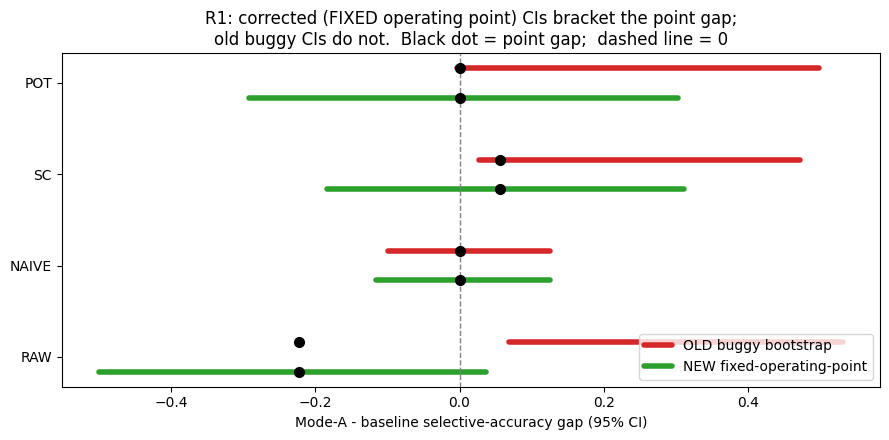

In [10]:
# ---- summary table ----
print(f"{'baseline':<8}{'point_gap':>11}   {'OLD buggy CI (p)':<26}{'br?':>5}   {'NEW fixed CI (p)':<26}{'br?':>5}")
print("-" * 92)
for base in ("pot", "sc", "naive", "raw"):
    d = r1["baselines"][base]
    oci, nci = d["reproduced_old_ci95"], d["new_ci95"]
    old_br = oci[0] <= d["point_gap"] <= oci[1]
    old_s = f"[{oci[0]:+.3f},{oci[1]:+.3f}] ({d['reproduced_old_boot_p']:.2f})"
    new_s = f"[{nci[0]:+.3f},{nci[1]:+.3f}] ({d['new_boot_p_gap_le_0']:.2f})"
    print(f"{base.upper():<8}{d['point_gap']:>+11.4f}   {old_s:<26}{str(old_br):>5}   "
          f"{new_s:<26}{str(d['ci_brackets_point_estimate']):>5}")

# ---- plot: point gaps with OLD (buggy) vs NEW (corrected) 95% CIs ----
bases = ["pot", "sc", "naive", "raw"]
fig, ax = plt.subplots(figsize=(9, 4.5))
for off, key, color, lab in [(-0.16, "reproduced_old_ci95", "tab:red", "OLD buggy bootstrap"),
                             (0.16, "new_ci95", "tab:green", "NEW fixed-operating-point")]:
    for i, base in enumerate(bases):
        d = r1["baselines"][base]
        lo, hi = d[key]
        ax.plot([lo, hi], [i + off, i + off], color=color, lw=4, solid_capstyle="round",
                label=lab if i == 0 else None)
        ax.plot(d["point_gap"], i + off, "o", color="black", ms=7, zorder=5)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_yticks(range(len(bases)))
ax.set_yticklabels([b.upper() for b in bases])
ax.set_xlabel("Mode-A - baseline selective-accuracy gap (95% CI)")
ax.set_title("R1: corrected (FIXED operating point) CIs bracket the point gap;\n"
             "old buggy CIs do not.  Black dot = point gap;  dashed line = 0")
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()